# My NumPy EncoderBlock vs PyTorch TransformerEncoderLayer

This notebook copies the same weights into both implementations, runs a forward pass on identical `float32` inputs. Compares accuracy and uses a heat map to visualize attention weights from the NumPy encoder.

## Step 1. Setup

Import libraries, resolve the project root on sys.path, import EncoderBlock, and fix random seeds so NumPy and PyTorch are fairly compared.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "attention").is_dir() else _cwd.parent
assert (REPO_ROOT / "attention").is_dir(), "Could not find attention/; run from repo root or notebook/"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from attention.encoder import EncoderBlock

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /Users/school/Documents/transfmr_attent_mechanism


## Step 2. Instantiate models

**Purpose:** Build your NumPy `EncoderBlock` and PyTorch `TransformerEncoderLayer` with the same hyperparameters (`d_model=64`, four heads, FFN width 256, GELU, `batch_first=True`). Two layers ready for weight transfer; PyTorch module in eval mode with `dropout=0` so stochastic behavior does not affect the comparison.

In [2]:
d_model = 64
num_heads = 4
d_ff = 256

encoder = EncoderBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff)

pt_encoder = nn.TransformerEncoderLayer(
    d_model=d_model,
    nhead=num_heads,
    dim_feedforward=d_ff,
    dropout=0.0,
    activation="gelu",
    batch_first=True,
    norm_first=False,
)
pt_encoder.eval()

print(encoder)
print(pt_encoder)

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (linear1): Linear(in_features=64, out_features=256, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (linear2): Linear(in_features=256, out_features=64, bias=True)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.0, inplace=False)
  (dropout2): Dropout(p=0.0, inplace=False)
)


## Step 3. Create input

**Purpose:** Build one sequence of length 10 and feature size 64 in NumPy (`float32`), then wrap it as a batch of size 1 for PyTorch `(1, seq_len, d_model)`.

**Result:** `x_np` and `x_pt` represent the same tensor in the two frameworks.

In [3]:
seq_len = 10

x_np = np.random.randn(seq_len, d_model).astype(np.float32)
x_pt = torch.from_numpy(x_np).unsqueeze(0).contiguous()

print("x_np:", x_np.shape, x_np.dtype)
print("x_pt:", tuple(x_pt.shape), x_pt.dtype)

x_np: (10, 64) float32
x_pt: (1, 10, 64) torch.float32


## Step 4. Copy weights 

**Purpose:** Make PyTorch use the same parameters as the NumPy encoder so the forward pass is directly comparable.

**Mappings (NumPy uses `y = x @ W + b` with `W` shaped `(in_features, out_features)`; `nn.Linear` stores `weight` as `(out_features, in_features)`, i.e. `W.T`):**

- **Q / K / V linear projections** → creates `self_attn.in_proj_weight`, `self_attn.in_proj_bias`. 
PyTorch fuses three separate d_model → d_model maps into one `Linear(d_model, 3 * d_model)`. 
The weight rows are stacked in order: **Q, K, V**. Each block is `W.T` for the corresponding NumPy weight matrix.

- **Attention output projection** `W_o`, `b_o` → is 'self_attn.out_proj' weight and bias
- **FFN:** `W1`, `b1` and `W2`, `b2` → weight and bias matrixes for layers 1 and 2
- **Post-attention LayerNorm** → has its own weight and bias matrix plus gamma and beta.
- **Post-FFN LayerNorm** → has its own weight and bias matrix

**Result** both models implement the same parameters.

In [4]:
d = d_model

with torch.no_grad():
    # --- Q, K, V fused in_proj: PyTorch stacks [Q; K; V] along the output dimension ---
    pt_encoder.self_attn.in_proj_weight[:d].copy_(torch.from_numpy(encoder.W_q.T))
    pt_encoder.self_attn.in_proj_weight[d : 2 * d].copy_(torch.from_numpy(encoder.W_k.T))
    pt_encoder.self_attn.in_proj_weight[2 * d :].copy_(torch.from_numpy(encoder.W_v.T))
    pt_encoder.self_attn.in_proj_bias[:d].copy_(torch.from_numpy(encoder.b_q))
    pt_encoder.self_attn.in_proj_bias[d : 2 * d].copy_(torch.from_numpy(encoder.b_k))
    pt_encoder.self_attn.in_proj_bias[2 * d :].copy_(torch.from_numpy(encoder.b_v))

    # --- Multi-head output projection (mixes concatenated heads back to d_model) ---
    pt_encoder.self_attn.out_proj.weight.copy_(torch.from_numpy(encoder.W_o.T))
    pt_encoder.self_attn.out_proj.bias.copy_(torch.from_numpy(encoder.b_o))

    # --- Position-wise FFN: GELU after the first linear only (matches TransformerEncoderLayer) ---
    pt_encoder.linear1.weight.copy_(torch.from_numpy(encoder.W1.T))
    pt_encoder.linear1.bias.copy_(torch.from_numpy(encoder.b1))
    pt_encoder.linear2.weight.copy_(torch.from_numpy(encoder.W2.T))
    pt_encoder.linear2.bias.copy_(torch.from_numpy(encoder.b2))

    # --- LayerNorm after the attention residual ---
    pt_encoder.norm1.weight.copy_(torch.from_numpy(encoder.ln1_gamma))
    pt_encoder.norm1.bias.copy_(torch.from_numpy(encoder.ln1_beta))

    # --- LayerNorm after the FFN residual ---
    pt_encoder.norm2.weight.copy_(torch.from_numpy(encoder.ln2_gamma))
    pt_encoder.norm2.bias.copy_(torch.from_numpy(encoder.ln2_beta))

print("Weights copied from NumPy EncoderBlock into PyTorch TransformerEncoderLayer.")

Weights copied from NumPy EncoderBlock into PyTorch TransformerEncoderLayer.


## Step 5. Forward pass

**Purpose:** Run `EncoderBlock.forward` on `x_np` and the PyTorch layer on `x_pt`.

**Result:** Two `(seq_len, d_model)` outputs in `float32` for comparison.

In [5]:
out_np = encoder.forward(x_np)

with torch.no_grad():
    out_pt = pt_encoder(x_pt).squeeze(0).numpy()

print("out_np:", out_np.shape, out_np.dtype)
print("out_pt:", out_pt.shape, out_pt.dtype)

out_np: (10, 64) float64
out_pt: (10, 64) float32


## Step 6. Compare outputs

**Purpose:** Quantify numerical agreement; require tight alignment because parameters and dtypes were matched explicitly.

**Expected outcome:** Max absolute difference below `1e-5`.

In [6]:
max_abs_diff = float(np.max(np.abs(out_np - out_pt)))
print(f"Max absolute difference: {max_abs_diff}")
assert max_abs_diff < 1e-5, f"max abs diff {max_abs_diff} >= 1e-5"

Max absolute difference: 3.8308632221983885e-07


## Step 7. Visualize attention

**Purpose:** Re-run the NumPy encoder now returning attention weights, take one head’s sequence vs squence weight matrix (rows ≈ query positions, columns ≈ key positions), and plot it as a heatmap.

**Result:** A labeled heatmap for a single head after softmax showing how the encoder maps relationships between tokens.

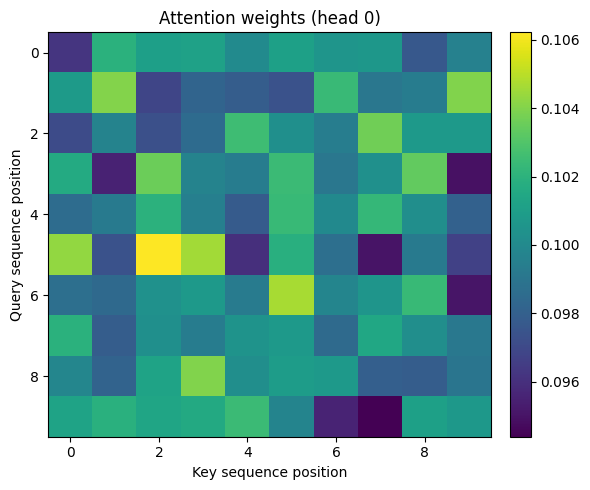

In [7]:
head_index = 0
encoder.forward(x_np, return_attention_weights=True)
weights = encoder.last_attention_weights  # (num_heads, seq_len, seq_len)
w = weights[head_index]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(w, aspect="auto", cmap="viridis")
ax.set_xlabel("Key sequence position")
ax.set_ylabel("Query sequence position")
ax.set_title(f"Attention weights (head {head_index})")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Notes


- `attention.multihead.multihead_attention` also has projection weights and biases (`W_q`, `W_k`, `W_v`, `W_o`, `b_q`, …) plus optional `return_attention_weights`. Those tensors are in the `EncoderBlock` and passed in so weights can be copied to PyTorch’s fused `in_proj` exactly for a fair comparison.

- **GELU:** NumPy `utils.gelu` uses the **erf** form to match `torch.nn.functional.gelu` used inside TransformerEncoderLayer for higher accuracy.
- **FFN:** Second linear has no activation, matching PyTorch.
- **LayerNorm:** Parameters `gamma` / `beta` are explicit on `EncoderBlock` and copied to `norm1` and `norm2`.